# Inteligência Artificial na Premier League: Random Forest

Nesta etapa, substituímos a estatística clássica (Poisson) por **Machine Learning**. 
O objetivo é treinar uma Floresta Aleatória (`RandomForestClassifier`) para encontrar padrões não lineares entre o desempenho recente das equipes e o resultado final da partida, mitigando a dificuldade do modelo anterior em prever empates.

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Carregando os Dados e Definindo o Alvo
url = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
df = pd.read_csv(url)
colunas_ml = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A']
df_ml = df[colunas_ml].copy()
df_ml['Target'] = df_ml['FTR'].map({'H': 2, 'D': 1, 'A': 0})

# 2. Feature Engineering: Calculando as médias dos últimos 5 jogos
times = pd.concat([df_ml['HomeTeam'], df_ml['AwayTeam']]).unique()
historico_gf = {time: [] for time in times}
historico_gs = {time: [] for time in times}
media_gf_casa, media_gs_casa, media_gf_fora, media_gs_fora = [], [], [], []

for index, row in df_ml.iterrows():
    t_casa, t_fora = row['HomeTeam'], row['AwayTeam']
    
    media_gf_casa.append(np.mean(historico_gf[t_casa][-5:]) if len(historico_gf[t_casa]) > 0 else 0)
    media_gs_casa.append(np.mean(historico_gs[t_casa][-5:]) if len(historico_gs[t_casa]) > 0 else 0)
    media_gf_fora.append(np.mean(historico_gf[t_fora][-5:]) if len(historico_gf[t_fora]) > 0 else 0)
    media_gs_fora.append(np.mean(historico_gs[t_fora][-5:]) if len(historico_gs[t_fora]) > 0 else 0)
    
    historico_gf[t_casa].append(row['FTHG'])
    historico_gs[t_casa].append(row['FTAG'])
    historico_gf[t_fora].append(row['FTAG'])
    historico_gs[t_fora].append(row['FTHG'])

df_ml['Casa_Med_GF_5J'] = media_gf_casa
df_ml['Casa_Med_GS_5J'] = media_gs_casa
df_ml['Fora_Med_GF_5J'] = media_gf_fora
df_ml['Fora_Med_GS_5J'] = media_gs_fora

df_ml = df_ml.iloc[50:].reset_index(drop=True) # Removendo período de aquecimento

### Treinamento, Probabilidades e Backtesting
Dividimos a base respeitando a cronologia (`shuffle=False`). A IA extrai as probabilidades justas (`predict_proba`) e o algoritmo financeiro simula as apostas na reta final do campeonato buscando 10% de Edge.

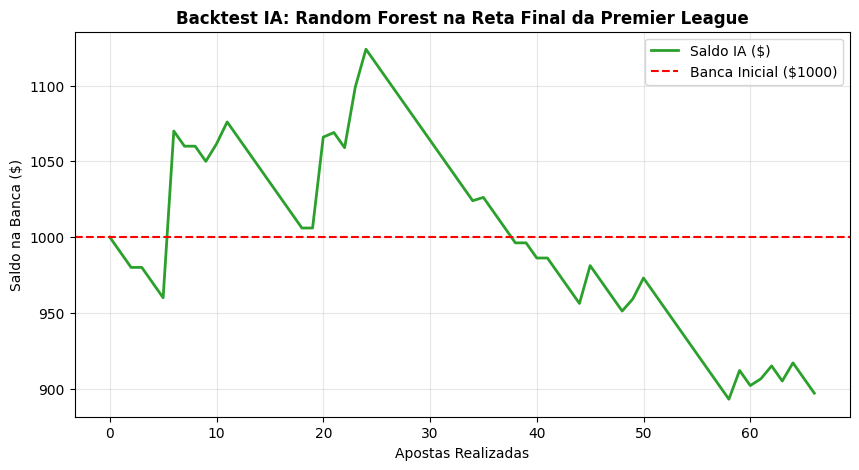

Total Entradas: 61 | Win Rate: 24.59% | ROI: -16.89%


In [ ]:
# 1. Separando Treino e Teste
features = ['Casa_Med_GF_5J', 'Casa_Med_GS_5J', 'Fora_Med_GF_5J', 'Fora_Med_GS_5J']
X = df_ml[features]
y = df_ml['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# 2. Treinando a Inteligência Artificial
modelo_ia = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_ia.fit(X_train, y_train)

# 3. Extraindo as Probabilidades e gerando Odds Justas
probabilidades = modelo_ia.predict_proba(X_test)
df_teste = df_ml.iloc[X_test.index].copy()
df_teste['Odd_IA_Fora'] = np.where(probabilidades[:, 0] > 0, 1 / probabilidades[:, 0], 999)
df_teste['Odd_IA_Empate'] = np.where(probabilidades[:, 1] > 0, 1 / probabilidades[:, 1], 999)
df_teste['Odd_IA_Casa'] = np.where(probabilidades[:, 2] > 0, 1 / probabilidades[:, 2], 999)

# 4. Backtesting Financeiro
banca_inicial = 1000.00
banca_atual = banca_inicial
historico_banca = [banca_atual]
apostas_feitas, apostas_ganhas = 0, 0
margem_seguranca = 1.10

for index, jogo in df_teste.iterrows():
    edge_casa = jogo['B365H'] / jogo['Odd_IA_Casa']
    edge_empate = jogo['B365D'] / jogo['Odd_IA_Empate']
    edge_fora = jogo['B365A'] / jogo['Odd_IA_Fora']
    
    melhor_aposta, maior_edge, odd_aposta = None, margem_seguranca, 0
    
    if edge_casa > maior_edge: melhor_aposta, maior_edge, odd_aposta = 'H', edge_casa, jogo['B365H']
    if edge_empate > maior_edge: melhor_aposta, maior_edge, odd_aposta = 'D', edge_empate, jogo['B365D']
    if edge_fora > maior_edge: melhor_aposta, maior_edge, odd_aposta = 'A', edge_fora, jogo['B365A']
        
    if melhor_aposta is not None:
        apostas_feitas += 1
        if melhor_aposta == jogo['FTR']: 
            banca_atual += 10.00 * (odd_aposta - 1)
            apostas_ganhas += 1
        else: banca_atual -= 10.00
    historico_banca.append(banca_atual)

# 5. Relatório e Gráfico
plt.figure(figsize=(10, 5))
plt.plot(historico_banca, color='#2ca02c', linewidth=2, label='Saldo IA ($)')
plt.axhline(y=banca_inicial, color='red', linestyle='--', label='Banca Inicial ($1000)')
plt.title('Backtest IA: Random Forest na Reta Final da Premier League', fontweight='bold')
plt.xlabel('Apostas Realizadas')
plt.ylabel('Saldo na Banca ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Total Entradas: {apostas_feitas} | Win Rate: {(apostas_ganhas/apostas_feitas)*100:.2f}% | ROI: {((banca_atual-banca_inicial)/(apostas_feitas*10.00))*100:.2f}%")